In [3]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from tqdm import tqdm
import torch


##Загрузка датасета

In [2]:
dataset = load_dataset("Anthropic/hh-rlhf")
print(f"Dataset loaded | Train: {len(dataset['train'])} | Test: {len(dataset['test'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

...

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

Dataset loaded | Train: 160800 | Test: 8552


##Кэширование эмбеддингов

In [4]:
MODEL_NAME = "all-mpnet-base-v2"
CACHE_DIR = "data/embeddings"
os.makedirs(CACHE_DIR, exist_ok=True)

def get_or_cache_embeddings(texts, filename):
    path = os.path.join(CACHE_DIR, f"{filename}.npy")
    if os.path.exists(path):
        print(f"Loading cached: {path}")
        return np.load(path)

    print(f"Encoding {len(texts)} texts with {MODEL_NAME}...")
    encoder = SentenceTransformer(MODEL_NAME)
    print(f"Model Device: {encoder.device}")
    embs = encoder.encode(
        texts,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    np.save(path, embs)
    print(f"Saved to {path} ({embs.nbytes / 1024**2:.1f} MB)")
    return embs

# Train split (полный датасет)
print("📦 Processing Train split...")
c_train = get_or_cache_embeddings(dataset["train"]["chosen"], "chosen_full_mpnet")
r_train = get_or_cache_embeddings(dataset["train"]["rejected"], "rejected_full_mpnet")

# Test split
print("📦 Processing Test split...")
c_test = get_or_cache_embeddings(dataset["test"]["chosen"], "chosen_test_mpnet")
r_test = get_or_cache_embeddings(dataset["test"]["rejected"], "rejected_test_mpnet")

print("\n✅ All embeddings loaded/cached successfully.")
print(f"Train shapes: chosen={c_train.shape}, rejected={r_train.shape}")
print(f"Test shapes:  chosen={c_test.shape}, rejected={r_test.shape}")

📦 Processing Train split...
Loading cached: data/embeddings/chosen_full_mpnet.npy
Loading cached: data/embeddings/rejected_full_mpnet.npy
📦 Processing Test split...
Loading cached: data/embeddings/chosen_test_mpnet.npy
Loading cached: data/embeddings/rejected_test_mpnet.npy

✅ All embeddings loaded/cached successfully.
Train shapes: chosen=(160800, 768), rejected=(160800, 768)
Test shapes:  chosen=(8552, 768), rejected=(8552, 768)


##Подготовка признаков (Аугментация)

In [5]:
def create_augmented_features(c_emb, r_emb):
    """Создаёт пары (chosen-rejected) и (rejected-chosen) для бинарной классификации"""
    diff_pos = c_emb - r_emb  # label = 1
    diff_neg = r_emb - c_emb  # label = 0
    X = np.vstack([diff_pos, diff_neg])
    y = np.concatenate([np.ones(len(diff_pos)), np.zeros(len(diff_neg))])
    return X, y

print("Forming features with swap augmentation...")
X_train, y_train = create_augmented_features(c_train, r_train)
X_test, y_test = create_augmented_features(c_test, r_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Classes (Train 0/1): {np.bincount(y_train.astype(int))}")
print(f"Classes (Test  0/1): {np.bincount(y_test.astype(int))}")

Forming features with swap augmentation...
Train: (321600, 768) | Test: (17104, 768)
Classes (Train 0/1): [160800 160800]
Classes (Test  0/1): [8552 8552]


##Обучение и сохранение модели

In [6]:
MODEL_PATH = "models/logreg_rlhf_final.pkl"
os.makedirs("models", exist_ok=True)

if os.path.exists(MODEL_PATH):
    print("Loading cached Logistic Regression...")
    clf = joblib.load(MODEL_PATH)
else:
    print("Training LogisticRegression (max_iter=1000, C=1.0)...")
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    joblib.dump(clf, MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")

print(f"Model ready. Coefficients shape: {clf.coef_.shape}")

Training LogisticRegression (max_iter=1000, C=1.0)...
Model saved to models/logreg_rlhf_final.pkl
Model ready. Coefficients shape: (1, 768)


##Финальная оценка на тесте + визуализации

Evaluating on official test set...

FINAL TEST RESULTS
Accuracy:  0.5673 (56.73%)
ROC-AUC:   0.6013
Baseline:  0.6400 (LogReg on 1k MiniLM)

Confusion Matrix:
                Predicted
                Good(1)  Bad(0)
Actual Good(1) [[   5150   3402  ]]
Actual Bad(0)  [[   3999   4553  ]]


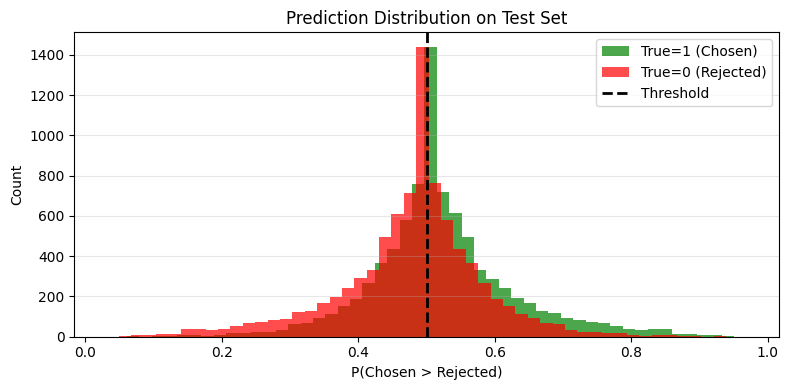

In [7]:
print("Evaluating on official test set...")
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\nFINAL TEST RESULTS")
print("="*55)
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC-AUC:   {auc:.4f}")
print("="*55)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("                Predicted")
print("                Good(1)  Bad(0)")
print(f"Actual Good(1) [[  {int(cm[1][1]):5d}  {int(cm[1][0]):5d}  ]]")
print(f"Actual Bad(0)  [[  {int(cm[0][1]):5d}  {int(cm[0][0]):5d}  ]]")

# Гистограмма вероятностей
plt.figure(figsize=(8, 4))
plt.hist(y_proba[y_test==1], bins=50, alpha=0.7, label='True=1 (Chosen)', color='green')
plt.hist(y_proba[y_test==0], bins=50, alpha=0.7, label='True=0 (Rejected)', color='red')
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.xlabel('P(Chosen > Rejected)')
plt.ylabel('Count')
plt.title('Prediction Distribution on Test Set')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

